In [ ]:
# import cac thu vien can dung
import pandas as pd
import gc
import matplotlib.pyplot as plt
from matplotlib import ticker
import seaborn as sns

# Ham ep kieu cho DataFrame de giam dung luong
def toi_uu_bo_nho(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            df[col] = pd.to_numeric(df[col], downcast='integer' if str(col_type).startswith('int') else 'float')
        else:
            if df[col].nunique() / len(df[col]) < 0.5:
                df[col] = df[col].astype('category')
    return df
print("Doc du lieu...")


Doc du lieu...


### ĐỌC BẢNG, LÀM SẠCH, TỐI ƯU BỘ NHỚ

In [ ]:
# Doc bang giao dich
df_transactions = pd.read_csv("transactions_data.csv")
# Lam sach so tien
if df_transactions["amount"].dtype == "object":
    df_transactions["amount"] = (
        df_transactions["amount"]
        .str.replace("$", "", regex=False)
        .astype(float)
    )
# Toi uu bo nho bang giao dich
df_transactions = toi_uu_bo_nho(df_transactions)


In [ ]:
# Doc bang thong tin the tin dung
df_cards = pd.read_csv("cards_data.csv")
# Toi uu bo nho bang thong tin the tin dung
df_cards = toi_uu_bo_nho(df_cards)


In [ ]:
# Doc bang thong tin nguoi dung
df_users = pd.read_csv("users_data.csv")

# Lam sach cac cot tien te
currency_cols = ["per_capita_income", "yearly_income", "total_debt"]
for col in currency_cols:
    df_users[col] = (
        df_users[col]
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

# Toi uu bo nho bang thong tin nguoi dung
df_users = toi_uu_bo_nho(df_users)


In [ ]:
# Doc bang nha cung cap dich vu
df_mcc = pd.read_csv('mcc_codes.csv')


In [ ]:
# Doc bang thong tin giao dich lua dao
df_fraud = pd.read_csv('train_fraud_labels.csv')


### GHÉP BẢNG, ĐỔI TÊN CỘT, XÓA BẢNG

In [ ]:
# Ghep bang giao dich voi bang the

df_merged = df_transactions.merge(
    df_cards,
    how="left",
    left_on="card_id",
    right_on="id"
)

# Doi ten cot id cua bang the de tranh nham
df_merged.rename(columns={"id_y": "card_id_tham_chieu"}, inplace=True)

# Xoa bang cu de tiet kiem bo nho
del df_transactions
del df_cards
gc.collect()


2124

In [ ]:
# Ghep bang tong voi bang nguoi dung 
df_merged = df_merged.merge(
    df_users,
    how="left",
    left_on="client_id_x",
    right_on="id"
)

# Doi ten cot id cua bang nguoi dung de tranh trung
df_merged.rename(columns={"id": "user_id_tham_chieu"}, inplace=True)

# Xoa bang nguoi dung de giai phong bo nho
del df_users
gc.collect()


0

In [ ]:
# Ghep bang tong voi bang nha cung cap dich vu
df_merged = df_merged.merge(
    df_mcc,
    how="left",
    left_on="mcc",
    right_on="mcc_code"
)

# Xoa bang MCC de giai phong bo nho
del df_mcc
gc.collect()


0

In [ ]:
# Ghep bang tong voi bang giao dich lua dao
df_merged = df_merged.merge(
    df_fraud,
    how="left",
    left_on="id_x",
    right_on="id"
)

# Xoa bang fraud de giai phong bo nho
del df_fraud
gc.collect()


0

In [ ]:

# ===== CHUAN HOA COT FRAUD =====
bang_chuyen_fraud = {
    'Yes': 1,
    'No': 0,
    'yes': 1,
    'no': 0
}
if 'label' in df_merged.columns:
    df_merged['is_fraud'] = df_merged['label'].map(bang_chuyen_fraud)
    df_merged['is_fraud'] = df_merged['is_fraud'].fillna(0).astype(int)
    df_merged.drop(columns=['label'], inplace=True)
else:
    df_merged['is_fraud'] = df_merged.get('is_fraud', 0)
    df_merged['is_fraud'] = df_merged['is_fraud'].fillna(0).astype(int)

# ===== XU LY THOI GIAN =====
df_merged['date'] = pd.to_datetime(df_merged['date'], errors='coerce')
df_merged['year'] = df_merged['date'].dt.year
df_merged['month'] = df_merged['date'].dt.month

# ===== LAM SACH DU LIEU GIAO DICH =====
# Loc truc tiep, khong tao DataFrame moi
df_merged = df_merged[df_merged['amount'] > 0]
df_merged = df_merged.dropna(subset=['date'])

print("So dong sau khi lam sach:", df_merged.shape[0])


Số dòng sau khi làm sạch: 12635227


### Khách hàng tiêu dùng bao nhiêu trong mỗi giao dịch của mình? 

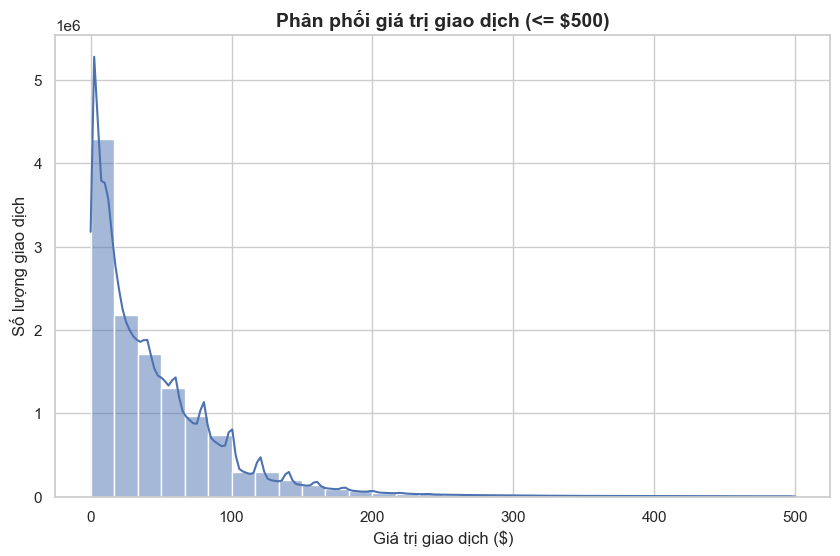

In [ ]:
# Loc giao dich <= $500 de loai bo outliers
df_plot = df_merged[df_merged['amount'] <= 500]

# Tao histogram voi duong cong mat do (KDE)
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_plot,
    x='amount',       # Truc x: gia tri giao dich
    bins=30,          # Chia thanh 30 cot
    kde=True          # Ve duong cong mat do
)

plt.title('Phan phoi gia tri giao dich (<= $500)')
plt.xlabel('Gia tri giao dich ($)')
plt.ylabel('So luong giao dich')
plt.show()


Ket luan: Khách hàng có xu hướng mua nhỏ lẻ, nhạy cảm về giá hoặc sản phẩm của doanh nghiệp chủ yếu là hàng tiêu dùng giá thấp.Doanh thu hiện tại phụ thuộc vào số lượng đơn hàng hơn là giá trị đơn hàng.
Giải pháp: Tạo các gói sản phẩm combo để khuyến khích khách chi tiêu nhiều hơn trong một lần mua, Gợi ý thêm các sản phẩm phụ kiện hoặc sản phẩm bổ trợ giá rẻ ngay lúc thanh toán để tăng nhẹ giá trị trung bình đơn hàng.

### Khách hàng thích sử dụng giao dịch trả trước hay trả sau?

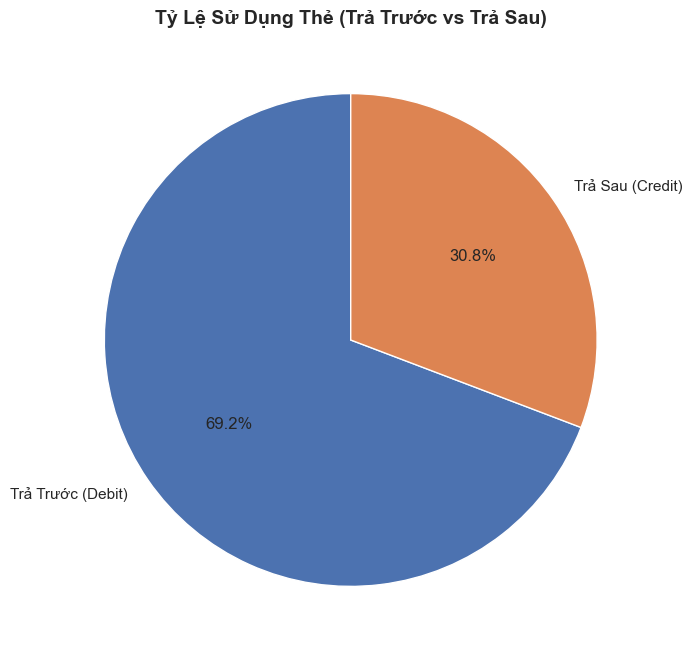

In [ ]:
# Bieu do tron can khung vuong
plt.figure(figsize=(8, 8))

# Tao cot phan loai: Credit (tra sau) vs Debit (tra truoc)
df_merged['payment_mode'] = df_merged['card_type'].apply(
    lambda x: 'Tra Sau (Credit)' if 'Credit' in str(x) else 'Tra Truoc (Debit)'
)

# Dem so luong tung loai the
dem_the = df_merged['payment_mode'].value_counts()

# Ve bieu do tron voi % tren moi phan
plt.pie(
    dem_the,
    labels=dem_the.index,
    autopct='%1.1f%%',    # Hien thi phan tram voi 1 so thap phan
    startangle=90         # Bat dau tu 90 do (12 gio)
)

plt.title('Ty Le Su Dung The (Tra Truoc vs Tra Sau)')
plt.show()


Khách hàng có tâm lý chi tiêu dựa trên số tiền thực có trong tài khoản thay vì vay mượn trả sau. giải pháp: Tung ra các ưu đãi giảm giá trực tiếp khi thanh toán ngay để khuyến khích và giữ chân nhóm khách hàng này.

### Đặc điểm của khách hàng của chúng ta là gì? 

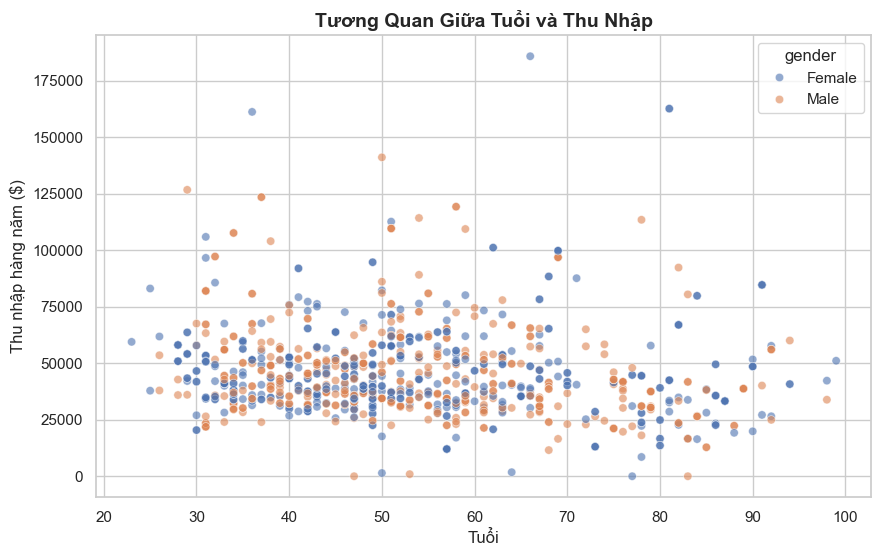

In [ ]:
# Lay mau 1000 dong neu du lieu qua lon (tranh lag)
plt.figure(figsize=(10, 6))

if len(df_merged) > 1000:
    du_lieu_ve = df_merged.sample(1000)
else:
    du_lieu_ve = df_merged

# Ve scatter plot: Tuoi vs Thu nhap, phan theo gioi tinh
sns.scatterplot(
    data=du_lieu_ve,
    x='current_age',
    y='yearly_income',
    hue='gender',         # Mau sac theo gioi tinh
    alpha=0.6             # Do trong suot de thay diem chong len nhau
)

plt.title('Tuong Quan Giua Tuoi va Thu Nhap')
plt.xlabel('Tuoi')
plt.ylabel('Thu nhap hang nam ($)')
plt.show()


Ket luan: Khách hàng là nhóm người tiêu dùng phổ thông có thu nhập trung bình, sống thực tế và ưu tiên chi tiêu an toàn trong giới hạn tài chính sẵn có.giải pháp: Nên tập trung vào các chiến dịch Marketing nhấn mạnh vào "Giá trị thực" (Value for money), các chương trình giảm giá thiết thực hoặc tích điểm đổi quà, thay vì xây dựng hình ảnh thương hiệu quá sang trọng hay xa cách.

### Những điều này thay đổi theo thời gian trong giai đoạn 2010 - 2019 như thế nào?

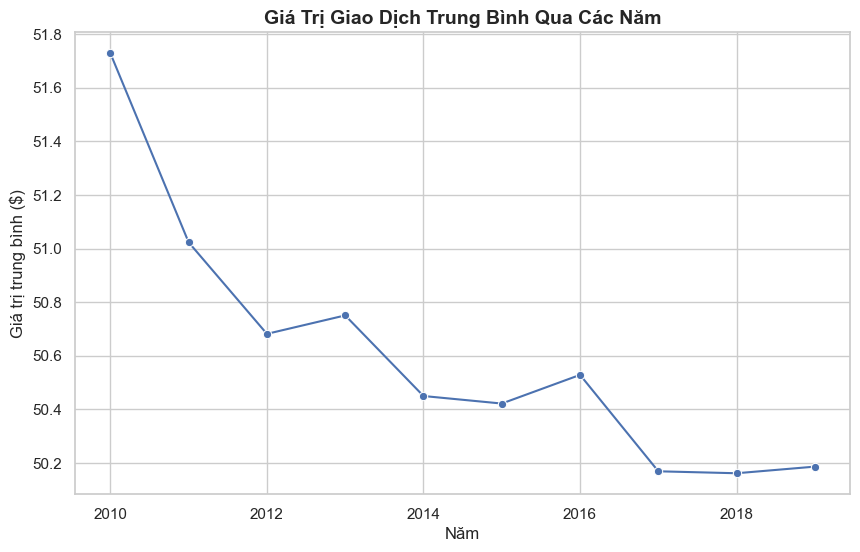

In [ ]:
plt.figure(figsize=(10, 6))

# Tinh gia tri giao dich trung binh theo tung nam
chi_tieu_theo_nam = (
    df_merged
    .groupby('year')['amount']
    .mean()                # Tinh trung binh
    .reset_index()
)

# Ve bieu do duong voi marker tron tai moi diem
sns.lineplot(
    data=chi_tieu_theo_nam,
    x='year',
    y='amount',
    marker='o'             # Danh dau tung nam bang cham tron
)

plt.title('Gia Tri Giao Dich Trung Binh Qua Cac Nam')
plt.xlabel('Nam')
plt.ylabel('Gia tri trung binh ($)')
plt.show()


Ket luan: Sức mua trên từng đơn hàng của khách đang suy yếu dần theo thời gian, cho thấy doanh nghiệp đang thất bại trong việc giữ vững giá trị đơn hàng  trước áp lực cạnh tranh hoặc thói quen thắt chặt chi tiêu của khách. Giai phap: Cần khẩn cấp triển khai các chiến lược kích cầu như bán combo  hoặc bán kèm tại quầy thu ngân để đảo ngược đà giảm và kéo giá trị trung bình đơn hàng đi lên.

## 4. Hãy đặt các câu hỏi và tìm cách trả lời qua dữ liệu. Hãy sáng tạo, lật nhiều góc độ, phối hợp các góc nhìn, tư duy think-out-of the box.


### Công ty đang tăng trưởng thế nào ?

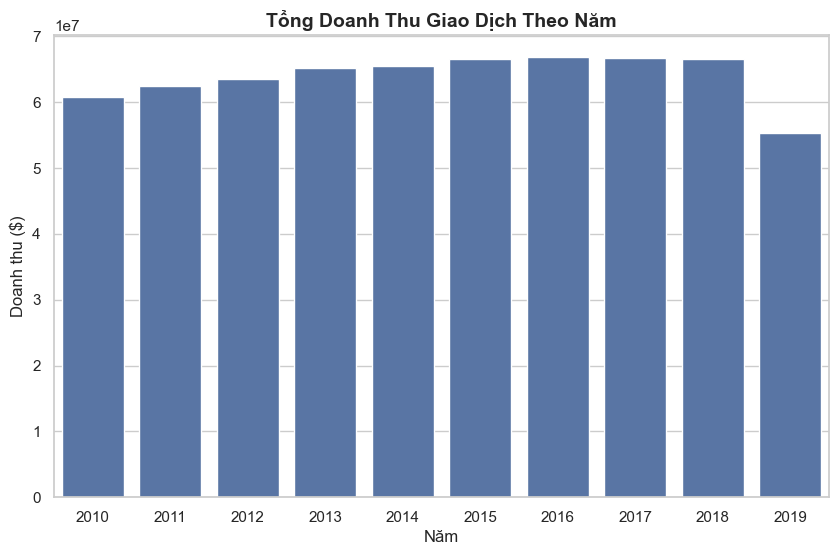

In [ ]:
# Tinh tong doanh thu theo tung nam (phan anh tang truong)
doanh_thu_theo_nam = (
    df_merged
    .groupby('year')['amount']
    .sum()                 # Tong tien giao dich
    .reset_index()
)

# Ve bieu do cot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=doanh_thu_theo_nam,
    x='year',
    y='amount'
)

plt.title('Tong Doanh Thu Giao Dich Theo Nam')
plt.xlabel('Nam')
plt.ylabel('Doanh thu ($)')
plt.show()


Ket luan: Công ty đang chấm dứt chu kỳ tăng trưởng và bước vào giai đoạn suy thoái đáng báo động khi doanh thu năm cuối lao dốc rõ rệt.Giải pháp: Cần khẩn trương điều tra nguyên nhân sụt giảm năm 2019-->do mất khách hay do đối thủ cạnh tranh để tái cơ cấu chiến lược kinh doanh ngay lập tức.

### Đâu là nhóm khách hàng chịu chi nhất ?

C:\Users\HOME\AppData\Local\Temp\ipykernel_8440\774979932.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['current_age', 'gender'])['amount']


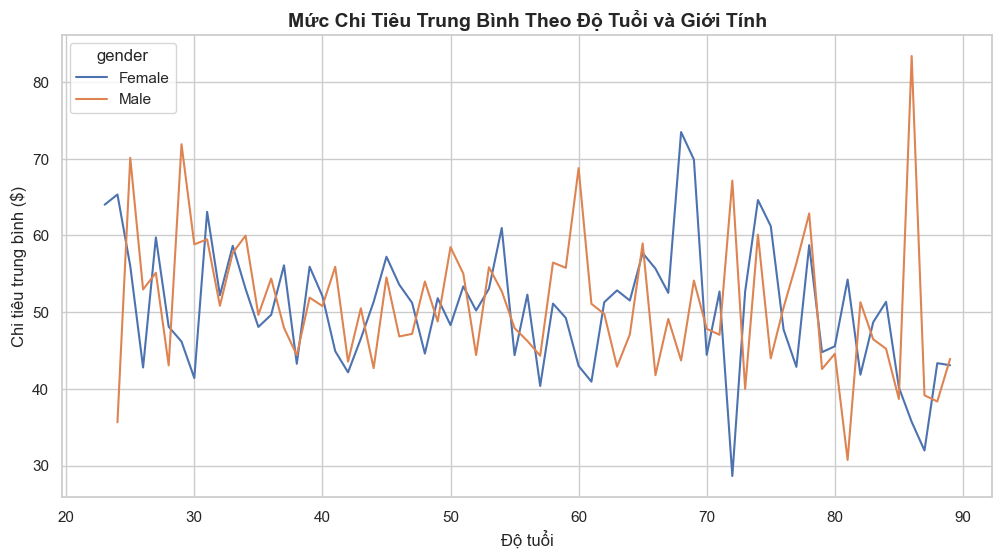

In [ ]:
# Loc nguoi dung co tuoi hop ly (< 90) de loai du lieu sai
du_lieu_tuoi = df_merged[df_merged['current_age'] < 90]

# Tinh chi tieu trung binh theo tuoi va gioi tinh
chi_tieu_theo_tuoi = (
    du_lieu_tuoi
    .groupby(['current_age', 'gender'])['amount']
    .mean()                # Trung binh theo nhom
    .reset_index()
)

# Ve bieu do duong so sanh nam/nu
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=chi_tieu_theo_tuoi,
    x='current_age',
    y='amount',
    hue='gender'           # 2 duong rieng cho nam/nu
)

plt.title('Muc Chi Tieu Trung Binh Theo Do Tuoi va Gioi Tinh')
plt.xlabel('Do tuoi')
plt.ylabel('Chi tieu trung binh ($)')
plt.show()


Kết luận: Hành vi tiêu dùng bị phân cực: nhóm trung niên (35-55) chi tiêu tiet kiem nhất, trong khi nhóm trẻ (thích trải nghiệm) và nhóm già (ổn định tài chính/nhu cầu đặc thù) lại sẵn sàng trả giá cao hơn cho mỗi đơn hàng. Giải pháp: Nên phân tách danh mục sản phẩm cao cấp  để nhắm riêng vào nhóm khách hàng lớn tuổi (như thực phẩm chức năng, quà tặng cao cấp) vì đây là nhóm khách hàng tiềm năng nhất để tăng giá trị đơn hàng 

### Khi nào kẻ gian hoạt động ?

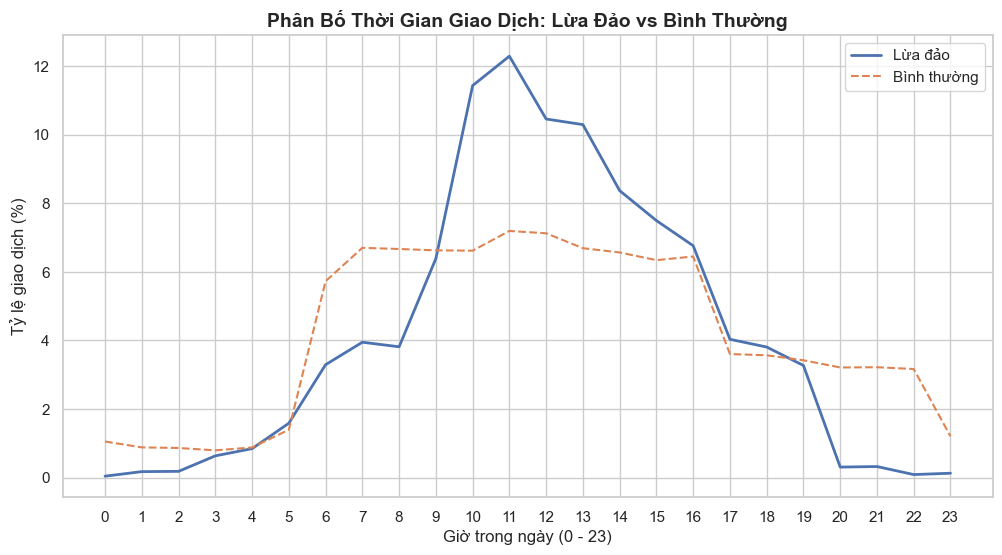

In [ ]:
# Trich xuat gio tu timestamp
df_merged['hour'] = df_merged['date'].dt.hour

# Tinh ty le % giao dich lua dao theo tung gio
fraud_by_hour = (
    df_merged[df_merged['is_fraud'] == 1]['hour']
    .value_counts(normalize=True)    # normalize=True → tinh %
    .sort_index() * 100
)

# Tinh ty le % giao dich binh thuong theo tung gio
normal_by_hour = (
    df_merged[df_merged['is_fraud'] == 0]['hour']
    .value_counts(normalize=True)
    .sort_index() * 100
)

# Ve 2 duong de so sanh
plt.figure(figsize=(12, 6))

plt.plot(
    fraud_by_hour.index,
    fraud_by_hour.values,
    label='Lua dao',
    linewidth=2
)

plt.plot(
    normal_by_hour.index,
    normal_by_hour.values,
    label='Binh thuong',
    linestyle='--'         # Net dut de phan biet
)

plt.title('Phan Bo Thoi Gian Giao Dich: Lua Dao vs Binh Thuong')
plt.xlabel('Gio trong ngay (0 - 23)')
plt.ylabel('Ty le giao dich (%)')
plt.xticks(range(0, 24))
plt.legend()
plt.show()


Kết luận Giao dịch lừa đảo không diễn ra lén lút vào ban đêm mà tập trung tấn công vào giờ cao điểm hành chính để dễ dàng trà trộn vào lượng lớn giao dịch thực tế nhằm qua mặt hệ thống kiểm soát.Giải pháp Cần tăng cường hệ thống cảnh báo tự động và nhân sự giám sát rủi ro đặc biệt chặt chẽ trong khung giờ từ 10 giờ đến 14 giờ hàng ngày để kịp thời ngăn chặn các hành vi bất thường.

### Dòng tiền của khách hàng chủ yếu chảy về đâu

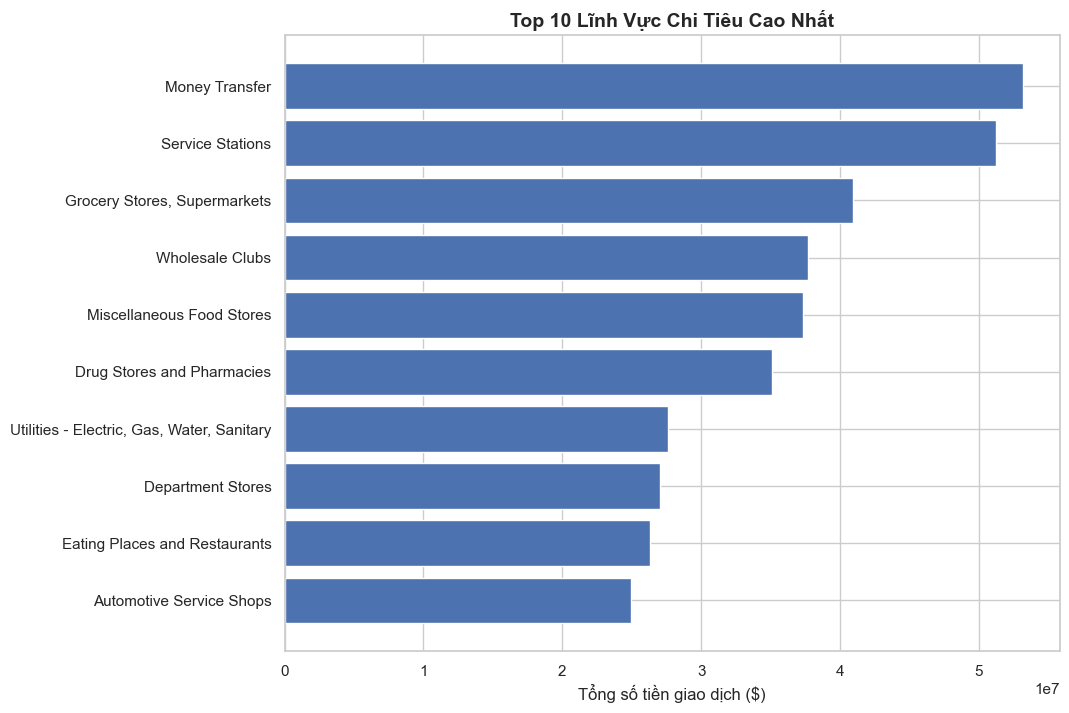

In [ ]:
# 1. Tinh tong tien theo tung linh vuc chi tieu (MCC) → lay top 10
top_chi_tieu = (
    df_merged
    .groupby('merchant_category')['amount']
    .sum()
    .sort_values(ascending=False)    # Sap xep giam dan
    .head(10)                         # Lay 10 linh vuc cao nhat
    .sort_values()                    # Sap xep tang dan de ve dep
)

# 2. Ve bieu do thanh ngang (de doc voi label dai)
plt.figure(figsize=(10, 8))

plt.barh(
    top_chi_tieu.index,
    top_chi_tieu.values
)

plt.title('Top 10 Linh Vuc Chi Tieu Cao Nhat')
plt.xlabel('Tong so tien giao dich ($)')
plt.ylabel('')
plt.show()
